In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical
# MNIST Dataset
from tensorflow.keras.datasets import mnist

In [12]:
df_train = pd.read_csv("/Users/sakshamchauhan/Downloads/Github/Data_Science/Deep_Learning/Lecture-2/mnist_train.csv")
df_test = pd.read_csv("/Users/sakshamchauhan/Downloads/Github/Data_Science/Deep_Learning/Lecture-2/mnist_test.csv")

In [13]:
df_train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [16]:
df_train.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [17]:
X_train = df_train.drop('label', axis=1).values
X_test = df_test.drop('label', axis=1).values

y_train = df_train['label'].values
y_test = df_test['label'].values

In [18]:
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [ ]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [20]:
# Flatting
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [21]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

2026-09-02 05:47:07.615371: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-09-02 05:47:07.616280: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-02 05:47:07.616369: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1788308227.616943 2385137 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788308227.618212 2385137 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
perceptron.compile(optimizer="sgd", loss = "categorical_crossentropy", metrics= ['accuracy'])

In [25]:
history_perc = perceptron.fit(X_train_img, y_train_cat, epochs= 20, batch_size=16, validation_data=(X_test_img, y_test_cat), verbose= 1)

Epoch 1/20


2026-09-02 05:49:22.766079: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.8419 - loss: 0.6269 - val_accuracy: 0.8945 - val_loss: 0.4022
Epoch 2/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - accuracy: 0.8928 - loss: 0.3929 - val_accuracy: 0.9059 - val_loss: 0.3481
Epoch 3/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.9015 - loss: 0.3562 - val_accuracy: 0.9107 - val_loss: 0.3288
Epoch 4/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.9063 - loss: 0.3374 - val_accuracy: 0.9146 - val_loss: 0.3144
Epoch 5/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.9095 - loss: 0.3253 - val_accuracy: 0.9158 - val_loss: 0.3062
Epoch 6/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - accuracy: 0.9113 - loss: 0.3168 - val_accuracy: 0.9159 - val_loss: 0.3014
Epoch 7/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - accuracy: 0.9140 - loss: 0.3100 - val_accuracy: 0.9185 - val_loss: 0.2948
Epoch 8/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.9151 - loss: 0.30

In [26]:
acc_perc = perceptron.evaluate(X_test_img, y_test_cat, verbose = 0)[1]
acc_perc

0.921999990940094

In [32]:
ANN = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128, activation= 'relu'),
    Dense(64, activation= 'relu'),
    Dense(10, activation= 'softmax'),
])

In [33]:
ANN.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics= ['accuracy'])

In [31]:
history_ANN = ANN.fit(X_train_img, y_train_cat, epochs = 5, batch_size = 32,
                      validation_data= (X_test_img, y_test_cat), verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.7883 - loss: 7.5384 - val_accuracy: 0.7266 - val_loss: 13.4650
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.7857 - loss: 11.2044 - val_accuracy: 0.7784 - val_loss: 16.9435
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.7860 - loss: 15.6948 - val_accuracy: 0.7699 - val_loss: 17.8316
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.7868 - loss: 20.2463 - val_accuracy: 0.8231 - val_loss: 16.1541
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.7853 - loss: 27.0706 - val_accuracy: 0.8413 - val_loss: 16.1178


In [37]:
acc_ANN = ANN.evaluate(X_test_img, y_test_cat, verbose = 0)[1]
acc_ANN

0.05719999969005585

In [39]:
X_train_img = X_train.reshape(-1,28,28,1)
X_test_img = X_test.reshape(-1,28,28,1)

In [40]:
CNN = Sequential([
    Conv2D(32, kernel_size = (3,3), activation = "relu", input_shape = (28,28,1)),
    MaxPooling2D(pool_size = (2,2)),
    Conv2D(64, kernel_size = (3,3), activation = "relu"),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),
    Dense(128, activation = "relu"),
    Dropout(0.5),
    Dense(10, activation = "softmax")
])

In [41]:
CNN.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ['accuracy'])

In [42]:
history_CNN = CNN.fit(X_train_img, y_train_cat, epochs = 5, batch_size = 32,
                      validation_data = (X_test_img, y_test_cat), verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9212 - loss: 0.2772 - val_accuracy: 0.9800 - val_loss: 0.0650
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9676 - loss: 0.1320 - val_accuracy: 0.9857 - val_loss: 0.0553
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9719 - loss: 0.1266 - val_accuracy: 0.9893 - val_loss: 0.0475
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9743 - loss: 0.1314 - val_accuracy: 0.9863 - val_loss: 0.0713
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9755 - loss: 0.1499 - val_accuracy: 0.9880 - val_loss: 0.0654


In [43]:
acc_CNN = CNN.evaluate(X_test_img, y_test_cat, verbose = 0)[1]
acc_CNN

0.9879999756813049

In [44]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

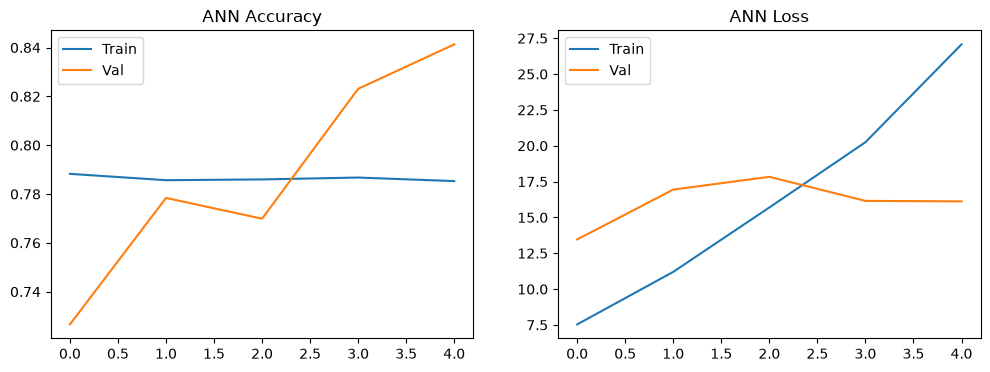

In [45]:
plot_training(history_ANN, "ANN")

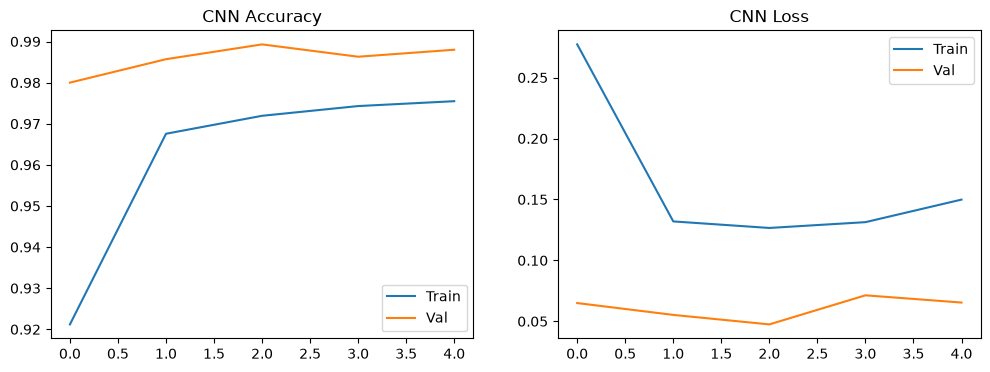

In [46]:
plot_training(history_CNN, "CNN")

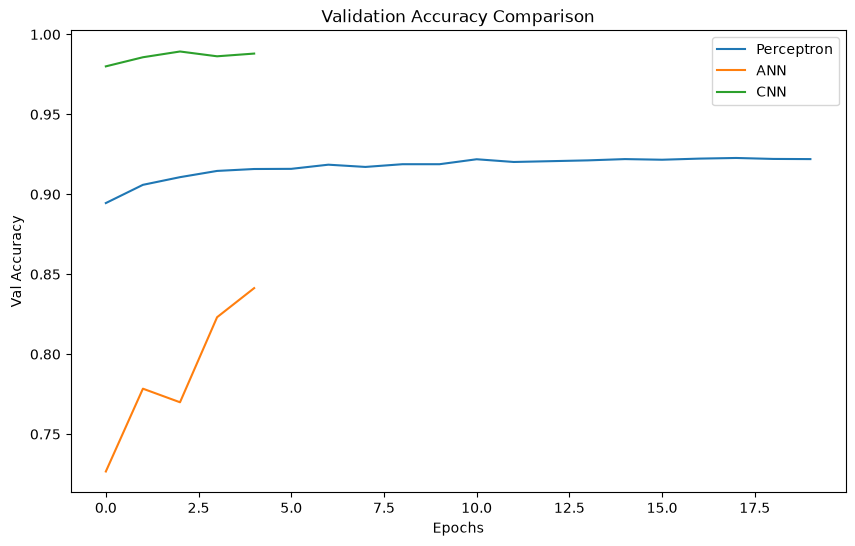

In [47]:
plt.figure(figsize=(10,6))
plt.plot(history_perc.history['val_accuracy'], label="Perceptron")
plt.plot(history_ANN.history['val_accuracy'], label="ANN")
plt.plot(history_CNN.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [48]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


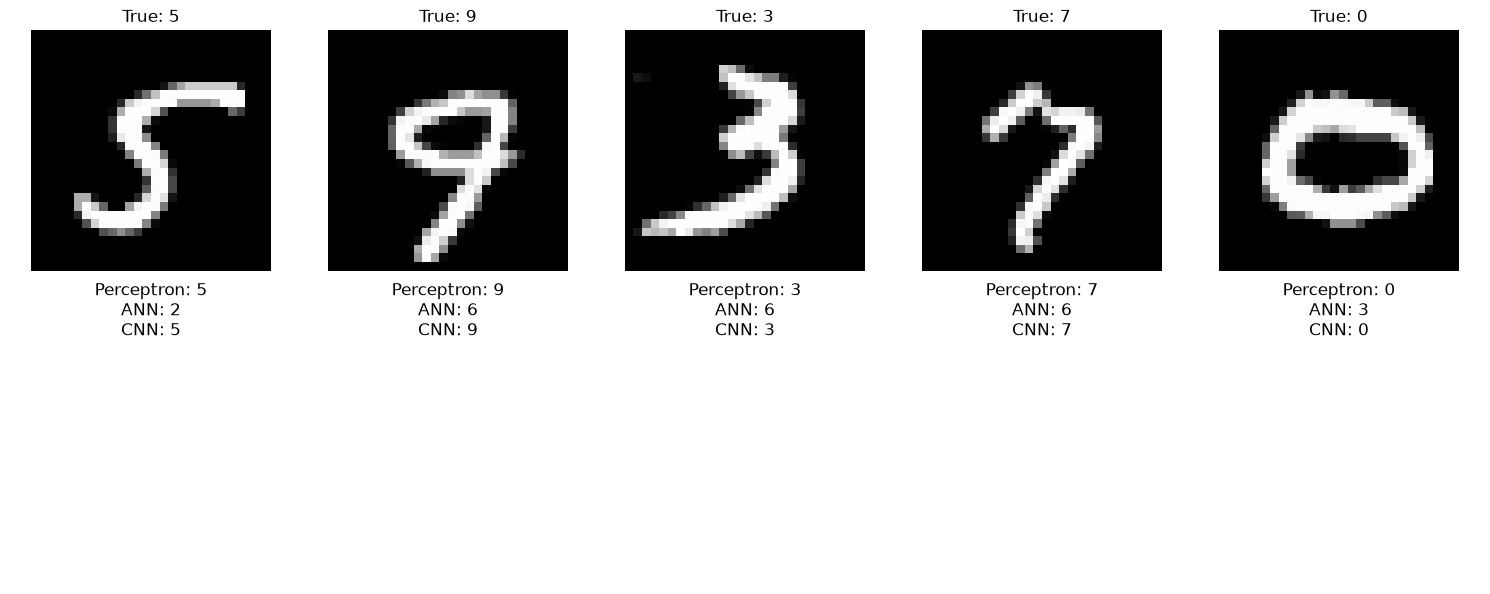

In [49]:
show_side_by_side([perceptron, ANN, CNN], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_img, y_test, 5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


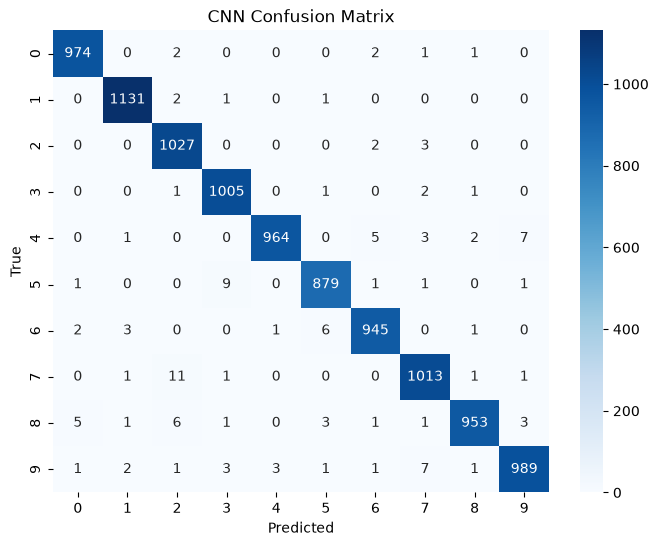

In [50]:
y_pred_cnn = np.argmax(CNN.predict(X_test_img), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

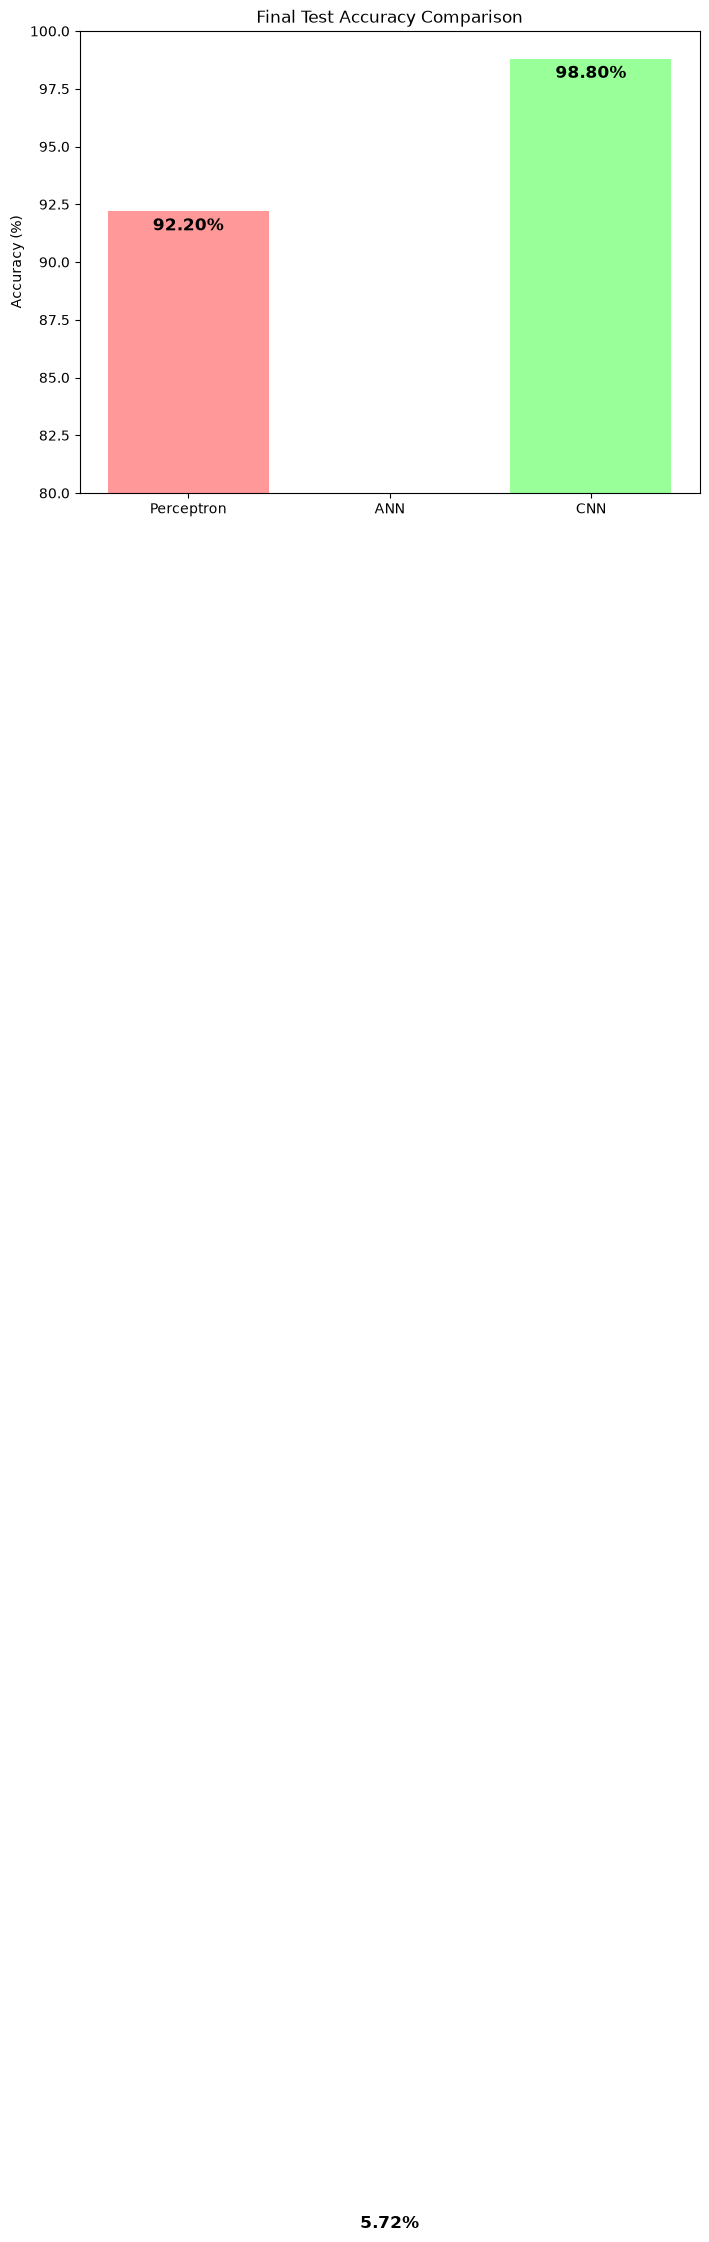

In [52]:
final_accs = [acc_perc*100, acc_ANN*100, acc_CNN*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()